## Install libraries

In [ ]:
!pip install -q pandas numpy scikit-learn plotly matplotlib nltk gensim lime requests pot shap

## Import Libraries

In [ ]:
import os
import shutil
import gzip

import requests

from gensim.models import KeyedVectors
import gensim.downloader as api

## Text model embedding

### Utility: Fast Download

In [ ]:
def _download_file_fast(url: str, output_path: str) -> None:
    """Download a file using streaming requests with a size sanity check.

    Args:
        url (str): File URL.
        output_path (str): Destination file path.

    Raises:
        IOError: If downloaded file is unexpectedly small.
        requests.exceptions.RequestException: If request fails.
    """
    print(f"Downloading from {url} => {output_path}")

    try:
        response = requests.get(url, stream=True, timeout=300)
        response.raise_for_status()

        min_expected_size_bytes: int = 100 * 1024 * 1024  # 100 MB
        downloaded_size: int = 0

        with open(output_path, "wb") as file:
            for chunk in response.iter_content(chunk_size=8192):
                if chunk:
                    file.write(chunk)
                    downloaded_size += len(chunk)

        if downloaded_size < min_expected_size_bytes:
            raise IOError(
                f"Downloaded file too small: {downloaded_size / (1024**2):.2f} MB"
            )

        print(f"Download completed: {downloaded_size / (1024**2):.2f} MB")

    except requests.exceptions.RequestException as error:
        if os.path.exists(output_path):
            os.remove(output_path)
        raise error

    except IOError as error:
        if os.path.exists(output_path):
            os.remove(output_path)
        raise error

### Utility: Gzip Extraction

In [ ]:
def _extract_gzip(gzip_path: str, output_path: str) -> None:
    """Extract a gzip file.

    Args:
        gzip_path (str): Path to .gz file.
        output_path (str): Output file path.
    """
    print(f"Extracting {gzip_path}...")

    with gzip.open(gzip_path, "rb") as src, open(output_path, "wb") as dst:
        shutil.copyfileobj(src, dst)

### Main Loader Function

In [ ]:
def load_embedding_model(
    model_name: str,
    cache_dir: str = "~/.cache/embeddings",
    force_download: bool = False,
) -> KeyedVectors:
    """Load a word embedding model with caching and fallback strategies.

    Supported models:
        - word2vec-google-news-300
        - glove.840B.300d
        - paragram_300_sl999

    Args:
        model_name (str): Name of the embedding model.
        cache_dir (str): Directory for storing cached models.
        force_download (bool): Force re-download.

    Returns:
        KeyedVectors: Loaded embedding model.

    Raises:
        RuntimeError: If model cannot be loaded.
    """
    cache_dir = os.path.expanduser(cache_dir)
    os.makedirs(cache_dir, exist_ok=True)

    model_file_map = {
        "word2vec-google-news-300": {
            "file": "GoogleNews-vectors-negative300.bin",
            "binary": True,
            "gensim": True,
        },
        "glove.840B.300d": {
            "file": "glove.840B.300d.txt",
            "binary": False,
            "gensim": True,
        },
        "paragram_300_sl999": {
            "file": "paragram_300_sl999.txt",
            "binary": False,
            "gensim": True,
        },
    }

    if model_name not in model_file_map:
        raise ValueError(f"Unsupported model: {model_name}")

    model_info = model_file_map[model_name]
    model_path = os.path.join(cache_dir, model_info["file"])

    # === 1. Load from cache ===
    if os.path.exists(model_path) and not force_download:
        print(f"Loading from cache: {model_path}")
        return KeyedVectors.load_word2vec_format(
            model_path,
            binary=model_info["binary"],
        )

    # === 2. Try gensim downloader ===
    if model_info["gensim"]:
        print(f"Loading via gensim: {model_name}")
        try:
            model = api.load(model_name)

            print(f"Saving to cache: {model_path}")
            model.save_word2vec_format(
                model_path,
                binary=model_info["binary"],
            )
            return model

        except Exception as error:
            print(f"Gensim failed: {error}")

    # === 3. Manual fallback (ONLY for GoogleNews) ===
    if model_name == "word2vec-google-news-300":
        gz_path = model_path + ".gz"
        download_url = (
            "https://public.ukp.informatik.tu-darmstadt.de/"
            "reimers/wordembeddings/GoogleNews-vectors-negative300.bin.gz"
        )

        try:
            _download_file_fast(download_url, gz_path)
            _extract_gzip(gz_path, model_path)

            return KeyedVectors.load_word2vec_format(model_path, binary=True)

        except Exception as error:
            raise RuntimeError("Failed to load GoogleNews model") from error

    raise RuntimeError(f"Failed to load model: {model_name}")

## SMILE Text Explanation using LIME

In [ ]:
from typing import Callable, Literal, Optional, Tuple, List, Dict
import numpy as np

from lime.lime_text import LimeTextExplainer
from gensim.models import KeyedVectors

EmbeddingName = Literal[
    "word2vec-google-news-300",
    "glove.840B.300d",
    "paragram_300_sl999",
]


class SmileTextExplainer(LimeTextExplainer):
    """SMILE explainer using semantic (WMD) distance instead of cosine.

    This class extends LIME by replacing cosine distance with Word Mover's
    Distance (WMD), with optimizations for practical performance.

    Args:
        embedding_name: Embedding model name.
        cache_dir: Directory to cache embeddings.
        use_wmd_cache: Cache WMD distances for speed.
        **kwargs: Passed to LimeTextExplainer.
    """

    def __init__(
        self,
        embedding_name: EmbeddingName = "word2vec-google-news-300",
        cache_dir: str = "~/.cache/embeddings",
        use_wmd_cache: bool = True,
        **kwargs,
    ) -> None:
        super().__init__(**kwargs)
        self.embedding_name: EmbeddingName = embedding_name
        self.cache_dir: str = cache_dir
        self.use_wmd_cache: bool = use_wmd_cache

        self.embedding_model: Optional[KeyedVectors] = None
        self._wmd_cache: Dict[Tuple[str, str], float] = {}

    def _get_embedding(self) -> KeyedVectors:
        """Lazy-load the embedding model and ensure internal norms are filled."""
        if self.embedding_model is None:
            # Assuming load_embedding_model is defined globally in your environment
            self.embedding_model = load_embedding_model(
                model_name=self.embedding_name,
                cache_dir=self.cache_dir,
            )
            self.embedding_model.fill_norms(force=True)

        return self.embedding_model

    def _wmd_distance(
        self,
        doc1_tokens: List[str],
        doc2_tokens: List[str],
    ) -> float:
        """Compute (cached) WMD distance between two token lists.

        Args:
            doc1_tokens: List of tokens from the first document.
            doc2_tokens: List of tokens from the second document.

        Returns:
            The Word Mover's Distance between the documents, or inf if OOV.
        """
        key = (" ".join(doc1_tokens), " ".join(doc2_tokens))

        if self.use_wmd_cache and key in self._wmd_cache:
            return self._wmd_cache[key]

        model = self._get_embedding()

        try:
            distance = model.wmdistance(doc1_tokens, doc2_tokens)
        except Exception:
            # Fallback if tokens are Out-Of-Vocabulary (OOV)
            distance = float("inf")

        if self.use_wmd_cache:
            self._wmd_cache[key] = distance

        return distance

    def _batch_wmd(
        self,
        original_tokens: List[str],
        perturbed_texts: List[str],
    ) -> np.ndarray:
        """Compute WMD distances for all perturbations efficiently.

        Args:
            original_tokens: Tokens of the base unperturbed text.
            perturbed_texts: List of raw strings representing perturbed sentences.

        Returns:
            A numpy array of computed distances.
        """
        distances: List[float] = []

        for text in perturbed_texts:
            tokens = text.split()
            dist = self._wmd_distance(original_tokens, tokens)
            distances.append(dist)

        return np.array(distances)

    def _LimeTextExplainer__data_labels_distances(  # noqa: N802
        self,
        indexed_string,
        classifier_fn: Callable,
        num_samples: int,
        distance_metric: str = "cosine",
    ) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
        """Override LIME distance with WMD-based semantic distance safely.

        Args:
            indexed_string: The internal LIME IndexedString instance.
            classifier_fn: Prediction function returning probabilities.
            num_samples: Total number of perturbation samples to generate.
            distance_metric: Unused parameter kept for signature matching.

        Returns:
            A tuple containing the perturbation matrix, predictions, and distances.
        """
        doc_size = indexed_string.num_words()
        sample = self.random_state.randint(1, doc_size + 1, num_samples - 1)

        data = np.ones((num_samples, doc_size))
        data[0] = np.ones(doc_size)

        features_range = range(doc_size)
        inverse_data: List[str] = [indexed_string.raw_string()]

        for i, size in enumerate(sample, start=1):
            inactive = self.random_state.choice(
                features_range, size, replace=False
            )
            data[i, inactive] = 0
            inverse_data.append(
                indexed_string.inverse_removing(inactive)
            )

        # === Model predictions ===
        labels = classifier_fn(inverse_data)

        # === SMILE distance (WMD) ===
        original_tokens = inverse_data[0].split()
        distances = self._batch_wmd(original_tokens, inverse_data)

        # === Safe Handle for Infinity / NaN values ===
        # Isolate valid, finite measurements to calculate a safe maximum scale
        finite_mask = np.isfinite(distances)
        finite_distances = distances[finite_mask]

        if len(finite_distances) > 0:
            max_finite_distance = np.max(finite_distances)
            # Use a large finite fallback value (max + a buffer) so that it
            # naturally results in a 0 weight without overflowing NumPy's squaring operation
            safe_fallback = max_finite_distance + 50.0
            distances[~finite_mask] = safe_fallback
        else:
            # Edge case fallback if everything in the batch ends up OOV
            distances[:] = 100.0

        distances = distances.reshape(-1)

        return data, labels, distances

## Data Loading

### Load Dataset

In [ ]:
from typing import List, Tuple
from sklearn.datasets import fetch_20newsgroups


def load_newsgroups_data(
    categories: List[str],
) -> Tuple:
    """Load train and test subsets of 20 Newsgroups dataset.

    Args:
        categories (List[str]): List of category names.

    Returns:
        Tuple: Train and test datasets.
    """
    train_data = fetch_20newsgroups(subset="train", categories=categories)
    test_data = fetch_20newsgroups(subset="test", categories=categories)
    return train_data, test_data


categories = ["alt.atheism", "soc.religion.christian"]
class_names = ["atheism", "christian"]

newsgroups_train, newsgroups_test = load_newsgroups_data(categories)

## Feature Engineering

### TF-IDF Vectorization

In [ ]:
import sklearn.feature_extraction.text as text


def build_vectorizer():
    """Create TF-IDF vectorizer.

    Returns:
        TfidfVectorizer: Configured vectorizer.
    """
    return text.TfidfVectorizer(lowercase=False)


vectorizer = build_vectorizer()

train_vectors = vectorizer.fit_transform(newsgroups_train.data)
test_vectors = vectorizer.transform(newsgroups_test.data)

## Model Training

### Train Classifier

In [ ]:
import sklearn.ensemble as ensemble


def train_random_forest(train_vectors, targets):
    """Train RandomForest classifier.

    Args:
        train_vectors: Feature matrix.
        targets: Target labels.

    Returns:
        RandomForestClassifier: Trained model.
    """
    model = ensemble.RandomForestClassifier(n_estimators=500)
    model.fit(train_vectors, targets)
    return model


rf = train_random_forest(train_vectors, newsgroups_train.target)

## Model Evaluation

### Compute F1 Score

In [ ]:
import sklearn.metrics as metrics


def evaluate_model(model, test_vectors, targets) -> float:
    """Evaluate model using F1 score.

    Args:
        model: Trained model.
        test_vectors: Feature matrix.
        targets: True labels.

    Returns:
        float: F1 score.
    """
    predictions = model.predict(test_vectors)
    return metrics.f1_score(targets, predictions, average="binary")


f1 = evaluate_model(rf, test_vectors, newsgroups_test.target)
print(f"F1 Score: {f1:.4f}")

F1 Score: 0.9231


## Pipeline Construction

### Build Sklearn Pipeline

In [ ]:
from sklearn.pipeline import make_pipeline


def build_pipeline(vectorizer, model):
    """Create sklearn pipeline.

    Args:
        vectorizer: Text vectorizer.
        model: Trained model.

    Returns:
        Pipeline: Combined pipeline.
    """
    return make_pipeline(vectorizer, model)


pipeline_model = build_pipeline(vectorizer, rf)

print(pipeline_model.predict_proba([newsgroups_test.data[0]]))

[[0.274 0.726]]


## SMILE Explanation instance

### Generate Explanation

In [ ]:
%%time
explainer = SmileTextExplainer(
    embedding_name="word2vec-google-news-300",
    cache_dir="~/.cache/google_news_vectors",
    class_names=class_names,
)

idx = 50
exp = explainer.explain_instance(
    newsgroups_test.data[idx],
    pipeline_model.predict_proba,
    num_features=6,
)


print(f"Document id: {idx}")
print(
    "Probability(christian) =",
    pipeline_model.predict_proba([newsgroups_test.data[idx]])[0, 1],
)
print("True class:", class_names[newsgroups_test.target[idx]])

Loading via gensim: word2vec-google-news-300
[==================================================] 100.0% 1662.8/1662.8MB downloaded
Saving to cache: /root/.cache/google_news_vectors/GoogleNews-vectors-negative300.bin
Document id: 50
Probability(christian) = 0.69
True class: christian
CPU times: user 4min 27s, sys: 38 s, total: 5min 5s
Wall time: 6min 33s


## Feature Impact Analysis

### Remove Features and Compare Predictions

In [ ]:
def analyze_feature_removal(
    model,
    vectorizer,
    test_vectors,
    index: int,
    words_to_remove: List[str],
) -> None:
    """Analyze impact of removing specific words.

    Args:
        model: Trained model.
        vectorizer: TF-IDF vectorizer.
        test_vectors: Feature matrix.
        index (int): Sample index.
        words_to_remove (List[str]): Words to remove.
    """
    original_prob = model.predict_proba(test_vectors[index])[0, 1]
    print("Original prediction:", original_prob)

    # convert to LIL format
    modified_vector = test_vectors[index].copy().tolil()

    for word in words_to_remove:
        if word in vectorizer.vocabulary_:
            col_idx = vectorizer.vocabulary_[word]
            modified_vector[0, col_idx] = 0

    # convert back to CSR for model inference
    modified_vector = modified_vector.tocsr()

    new_prob = model.predict_proba(modified_vector)[0, 1]

    print("Modified prediction:", new_prob)
    print("Difference:", new_prob - original_prob)


analyze_feature_removal(
    rf,
    vectorizer,
    test_vectors,
    idx,
    words_to_remove=["Posting", "Host"],
)

Original prediction: 0.69
Modified prediction: 0.69
Difference: 0.0


## Visualization

### Plot Explanation

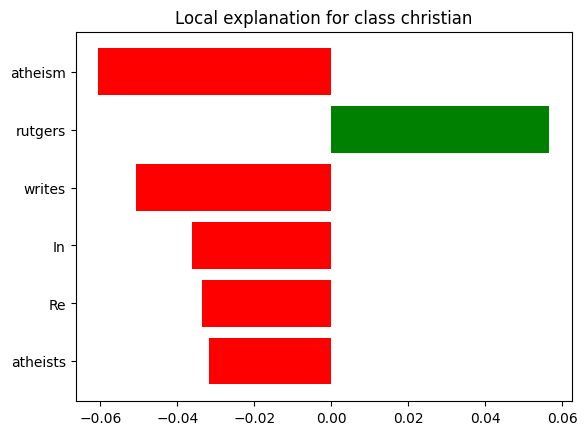

In [ ]:
def plot_explanation(exp):
    """Plot LIME explanation.

    Args:
        exp: LIME explanation object.
    """
    return exp.as_pyplot_figure()


fig = plot_explanation(exp)

### HTML Visualization

In [ ]:
from IPython.display import HTML


def render_html(exp):
    """Render LIME explanation as HTML.

    Args:
        exp: LIME explanation object.

    Returns:
        HTML: Rendered HTML.
    """
    return HTML(exp.as_html())


render_html(exp)

### Plot Explainer Comparision

In [ ]:
from typing import Dict, List, Tuple

import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots


def plot_explainer_comparison(
    explanations: Dict[str, Tuple[List[float], List[str]]],
    title: str = "Explainer Comparison",
    height: int = 600,
    width_per_plot: int = 500,
) -> None:
    """
    Compare multiple explanation methods using horizontal bar charts.

    Supported explainers:
        - SMILE
        - LIME
        - SHAP
        - Any custom explainer name

    Args:
        explanations:
            Dictionary format:
            {
                "SMILE": (weights, features),
                "LIME": (weights, features),
                "SHAP": (weights, features),
            }

            Example:
            {
                "SMILE": ([0.8, 0.4], ["god", "church"]),
                "LIME": ([0.7, 0.3], ["god", "faith"]),
            }

        title:
            Figure title.

        height:
            Plot height.

        width_per_plot:
            Width allocated for each subplot.
    """

    # -------------------------------------------------------------- #
    # Validate Inputs
    # -------------------------------------------------------------- #
    if not explanations:
        raise ValueError("`explanations` cannot be empty.")

    valid_explanations: Dict[str, Tuple[List[float], List[str]]] = {}

    for name, value in explanations.items():

        if value is None:
            continue

        if len(value) != 2:
            raise ValueError(
                f"{name} must contain (weights, features)."
            )

        weights, features = value

        if len(weights) != len(features):
            raise ValueError(
                f"{name}: weights and features must have same length."
            )

        valid_explanations[name] = (weights, features)

    if not valid_explanations:
        raise ValueError("No valid explanations provided.")

    # -------------------------------------------------------------- #
    # Dynamic subplot creation
    # -------------------------------------------------------------- #
    explainer_names: List[str] = list(valid_explanations.keys())
    num_explainers: int = len(explainer_names)

    fig = make_subplots(
        rows=1,
        cols=num_explainers,
        subplot_titles=tuple(explainer_names),
    )

    # -------------------------------------------------------------- #
    # Add traces
    # -------------------------------------------------------------- #
    for col_index, explainer_name in enumerate(explainer_names, start=1):

        weights, features = valid_explanations[explainer_name]

        weights_array = np.array(weights)

        fig.add_trace(
            go.Bar(
                x=weights,
                y=features,
                orientation="h",
                marker=dict(
                    color=np.argsort(weights_array),
                    coloraxis="coloraxis",
                ),
                name=explainer_name,
            ),
            row=1,
            col=col_index,
        )

    # -------------------------------------------------------------- #
    # Layout
    # -------------------------------------------------------------- #
    fig.update_layout(
        title_text=title,
        height=height,
        width=max(width_per_plot * num_explainers, 700),
        showlegend=False,
        coloraxis=dict(
            colorscale="Bluered_r",
        ),
    )

    fig.show()

### Plot Text Heatmap

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.transforms as transforms
import numpy as np
from typing import List, Union

def plot_text_heatmap(
    words: List[str],
    scores: Union[List[float], np.ndarray],
    title: str = "",
    width: float = 10.0,
    height: float = 0.2,
    verbose: int = 0,
    max_words_per_line: int = 20
) -> None:
    """Plots a text-based heatmap where words are highlighted based on their scores.

    Args:
        words: A list of text tokens/words to display.
        scores: An array or list of numerical scores associated with each word.
        title: The title of the plot. Defaults to "".
        width: Figure width in inches. Defaults to 10.0.
        height: Figure height in inches. Defaults to 0.2.
        verbose: Verbosity level. >0 prints lengths, >1 prints raw/normalized scores.
            Defaults to 0.
        max_words_per_line: Maximum number of words allowed before wrapping to a
            new line. Defaults to 20.

    Raises:
        ValueError: If input lists are empty, lengths mismatch, or max_words_per_line
            is invalid.
    """
    # Input Validation Checks
    if not words or scores is None or len(scores) == 0:
        raise ValueError("Both 'words' and 'scores' arguments must contain elements.")

    if len(words) != len(scores):
        raise ValueError(
            f"Length mismatch: 'words' has length {len(words)}, "
            f"but 'scores' has length {len(scores)}."
        )

    if max_words_per_line <= 0:
        raise ValueError("The 'max_words_per_line' parameter must be greater than 0.")

    # Initialize the figure and axis
    plt.figure(figsize=(width, height))
    axis = plt.gca()
    axis.set_title(title, loc='left')

    if verbose > 0:
        print(f"len words : {len(words)} | len scores : {len(scores)}")

    # Setup the colormap mapping normalized scores to colors
    color_map = plt.cm.ScalarMappable(cmap=cm.bwr)
    color_map.set_clim(0, 1)

    canvas = axis.figure.canvas
    transform = axis.transData

    # Normalize scores: negative scores in [0, 0.5], positive scores in (0.5, 1]
    max_absolute_score = np.max(np.abs(scores))
    if max_absolute_score == 0:
        # Fallback handle if all scores are 0 to prevent division by zero
        normalized_scores = np.full_like(scores, 0.5, dtype=float)
    else:
        normalized_scores = 0.5 * np.array(scores) / max_absolute_score + 0.5

    if verbose > 1:
        print("Raw score")
        print(scores)
        print("Normalized score")
        print(normalized_scores)

    # Initial vertical offset to prevent overlap with the title
    y_coordinate = -0.2

    for index, token in enumerate(words):
        # Extract RGB values and format them into a hex color string
        *rgb_values, _ = color_map.to_rgba(normalized_scores[index], bytes=True)
        hex_color = f"#{tuple(rgb_values)[0]:02x}{tuple(rgb_values)[1]:02x}{tuple(rgb_values)[2]:02x}"

        # Render the text box with its corresponding background color
        text_element = axis.text(
            x=0.0,
            y=y_coordinate,
            s=token,
            bbox={
                'facecolor': hex_color,
                'pad': 5.0,
                'linewidth': 1,
                'boxstyle': 'round,pad=0.5'
            },
            transform=transform,
            fontsize=14
        )

        text_element.draw(canvas.get_renderer())
        window_extent = text_element.get_window_extent()

        # Wrap text to a new line if the word limit for the line is reached
        if (index + 1) % max_words_per_line == 0:
            y_coordinate -= 2.5
            transform = axis.transData
        else:
            # Enhanced spacing to dynamically accommodate for the round bounding box padding
            transform = transforms.offset_copy(
                text_element._transform,
                x=window_extent.width + 20,
                units='dots'
            )

    if verbose == 0:
        axis.axis('off')

## Explanation Data Extraction

### Extract Weights and Features

In [ ]:
import numpy as np


def extract_explanation_details(exp, label: int = 1):
    """Extract feature weights and names from explanation.

    Args:
        exp: LIME explanation object.
        label (int): Target class index.

    Returns:
        Tuple[List[str], np.ndarray]: Features and weights.
    """
    weights = [weight for _, weight in exp.local_exp[label]]
    features = [feat for feat, _ in exp.as_list()]

    return features, np.array(weights)


features, weights = extract_explanation_details(exp)

print(weights)
print(features)

[-0.06060476  0.05657725 -0.05081376 -0.03628835 -0.03365471 -0.03190713]
[np.str_('atheism'), np.str_('rutgers'), np.str_('writes'), np.str_('In'), np.str_('Re'), np.str_('atheists')]


### Extract SHAP Features and Weights

In [ ]:
from typing import List, Tuple
import numpy as np


def extract_shap_explanation_details(
    shap_explanation,
    class_index: int = 1,
    top_k: int = 6,
) -> Tuple[List[str], List[float]]:
    """
    Extract top-k SHAP features and their importance weights.

    This version normalizes SHAP token output to make it comparable
    with LIME and SMILE explanations.

    Args:
        shap_explanation:
            SHAP explanation object (output of shap.Explainer).

        class_index:
            Target class index for classification models.

        top_k:
            Number of most important features to return.

    Returns:
        Tuple of:
            - features: List of tokens (cleaned)
            - weights: List of SHAP values (floats)
    """

    # -------------------------------------------------------------- #
    # Extract tokens
    # -------------------------------------------------------------- #
    tokens = shap_explanation.data[0]

    # Normalize tokens (handles np.str_, whitespace, etc.)
    tokens = [str(t).strip() for t in tokens]

    # -------------------------------------------------------------- #
    # Extract SHAP values for selected class
    # -------------------------------------------------------------- #
    values = shap_explanation.values[0, :, class_index]
    values = np.asarray(values, dtype=float)

    # -------------------------------------------------------------- #
    # Top-k selection by absolute importance
    # -------------------------------------------------------------- #
    if top_k >= len(values):
        idx = np.argsort(np.abs(values))[::-1]
    else:
        idx = np.argsort(np.abs(values))[-top_k:][::-1]

    # -------------------------------------------------------------- #
    # Build outputs
    # -------------------------------------------------------------- #
    features = [tokens[i] for i in idx]
    weights = [float(values[i]) for i in idx]

    return features, weights

In [ ]:
plot_explainer_comparison(
    explanations={
        "SMILE": (weights, features)
    },
    title="SMILE",
)

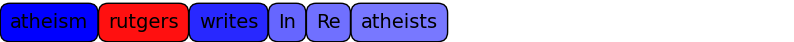

In [ ]:
plot_text_heatmap(
    words=features,
    scores=weights,
)

# Comparision

## Case 1

In [ ]:
num_features = 6

### SMILE

In [ ]:
explainer = SmileTextExplainer(
    embedding_name="word2vec-google-news-300",
    cache_dir="~/.cache/google_news_vectors",
    class_names=class_names,
)

idx = 50
exp = explainer.explain_instance(
    newsgroups_test.data[idx],
    pipeline_model.predict_proba,
    num_features=num_features,
)


print(f"Document id: {idx}")
print(
    "Probability(christian) =",
    pipeline_model.predict_proba([newsgroups_test.data[idx]])[0, 1],
)
print("True class:", class_names[newsgroups_test.target[idx]])


smile_features, smile_weights = extract_explanation_details(exp)

print(smile_weights)
print(smile_features)

Loading from cache: /root/.cache/google_news_vectors/GoogleNews-vectors-negative300.bin
Document id: 50
Probability(christian) = 0.69
True class: christian
[-0.06076704  0.0550452  -0.05119572 -0.03520598 -0.03312888 -0.03154844]
[np.str_('atheism'), np.str_('rutgers'), np.str_('writes'), np.str_('Re'), np.str_('In'), np.str_('atheists')]


In [ ]:
plot_explainer_comparison(
    explanations={
        "SMILE": (smile_weights, smile_features)
    },
    title="SMILE",
)

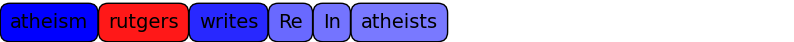

In [ ]:
plot_text_heatmap(
    words=smile_features,
    scores=smile_weights,

)

### LIME

In [ ]:
from lime.lime_text import LimeTextExplainer

explainer = LimeTextExplainer(class_names=class_names)

idx = 50
exp = explainer.explain_instance(
    newsgroups_test.data[idx],
    pipeline_model.predict_proba,
    num_features=num_features,
)


print(f"Document id: {idx}")
print(
    "Probability(christian) =",
    pipeline_model.predict_proba([newsgroups_test.data[idx]])[0, 1],
)
print("True class:", class_names[newsgroups_test.target[idx]])


lime_features, lime_weights = extract_explanation_details(exp)

print(lime_weights)
print(lime_features)

Document id: 50
Probability(christian) = 0.69
True class: christian
[ 0.06012343 -0.05587341  0.04303422 -0.04154916 -0.02669592  0.02500365]
[np.str_('rutgers'), np.str_('atheism'), np.str_('athos'), np.str_('writes'), np.str_('Re'), np.str_('1993')]


In [ ]:
plot_explainer_comparison(
    explanations={
        "LIME": (lime_weights, lime_features)
    },
    title="LIME",
)

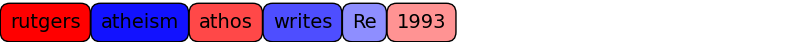

In [ ]:
plot_text_heatmap(
    words=lime_features,
    scores=lime_weights,
)

### SHAP

In [ ]:
import shap

idx = 50

# -------------------------------------------------------------- #
# Create SHAP text masker
# -------------------------------------------------------------- #
masker = shap.maskers.Text()

# -------------------------------------------------------------- #
# Create SHAP explainer
# -------------------------------------------------------------- #
explainer = shap.Explainer(
    pipeline_model.predict_proba,
    masker=masker,
)

# -------------------------------------------------------------- #
# Explain instance
# -------------------------------------------------------------- #
shap_exp = explainer(
    [newsgroups_test.data[idx]]
)

# -------------------------------------------------------------- #
# Print prediction details
# -------------------------------------------------------------- #
print(f"Document id: {idx}")

print(
    "Probability(christian) =",
    pipeline_model.predict_proba(
        [newsgroups_test.data[idx]]
    )[0, 1],
)

print(
    "True class:",
    class_names[newsgroups_test.target[idx]],
)

# -------------------------------------------------------------- #
# Extract SHAP features + weights
# -------------------------------------------------------------- #
shap_features, shap_weights = extract_shap_explanation_details(
    shap_exp,
    class_index=1,
    top_k=num_features,
)

print(shap_weights)
print(shap_features)

Document id: 50
Probability(christian) = 0.69
True class: christian
[0.03427181739631337, 0.03427181739631337, -0.016951388888888887, -0.016951388888888887, -0.016951388888888887, -0.01575347222222222]
['athos.', 'rutgers.', 'amongst', 'atheism,', 'other', 'alt.']


In [ ]:
plot_explainer_comparison(
    explanations={
        "SHAP": (shap_weights, shap_features)
    },
    title="SHAP",
)

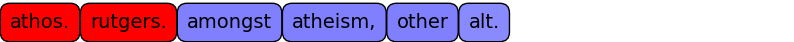

In [ ]:
plot_text_heatmap(
    words=shap_features,
    scores=shap_weights,
)

### Comparision together

In [ ]:
plot_explainer_comparison(
    explanations={
        "SMILE": (smile_weights, smile_features),
        "LIME": (lime_weights, lime_features),
        "SHAP": (shap_weights, shap_features),
    },
    title="Comparing SMILE, LIME, and SHAP",
)

## Case 2

In [ ]:
# -------------------------------------------------------------- #
# Input text
# -------------------------------------------------------------- #
text = "I believe in god who creates the entire planet"
num_features = len(text.split())

### SMILE

In [ ]:
# -------------------------------------------------------------- #
# Create explainer
# -------------------------------------------------------------- #
explainer = SmileTextExplainer(
    embedding_name="word2vec-google-news-300",
    cache_dir="~/.cache/google_news_vectors",
    class_names=class_names,
)

# -------------------------------------------------------------- #
# Generate explanation
# -------------------------------------------------------------- #
exp = explainer.explain_instance(
    text,
    pipeline_model.predict_proba,
    num_features=num_features,
)


# -------------------------------------------------------------- #
# Prediction details
# -------------------------------------------------------------- #
prediction_probs = pipeline_model.predict_proba([text])[0]

predicted_class_index = prediction_probs.argmax()

print("Input text:")
print(text)

print("\nPrediction probabilities:")
print(prediction_probs)

print(
    "\nPredicted class:",
    class_names[predicted_class_index],
)


# -------------------------------------------------------------- #
# Extract features + weights
# -------------------------------------------------------------- #
smile_features, smile_weights = extract_explanation_details(exp)

print("\nWeights:")
print(smile_weights)

print("\nFeatures:")
print(smile_features)

Loading from cache: /root/.cache/google_news_vectors/GoogleNews-vectors-negative300.bin


Input text:
I believe in god who creates the entire planet

Prediction probabilities:
[0.124 0.876]

Predicted class: christian

Weights:
[-5.38870189e-02  1.57120990e-02  8.74202582e-03 -1.98168303e-03
 -1.27582163e-03 -8.59091327e-04  4.96453118e-04 -4.63453009e-04
 -9.84510815e-05]

Features:
[np.str_('god'), np.str_('in'), np.str_('the'), np.str_('entire'), np.str_('believe'), np.str_('creates'), np.str_('who'), np.str_('planet'), np.str_('I')]


In [ ]:
plot_explainer_comparison(
    explanations={
        "SMILE": (smile_weights, smile_features)
    },
    title="SMILE",
)

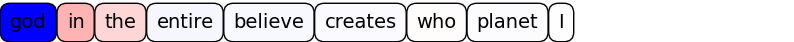

In [ ]:
plot_text_heatmap(
    words=smile_features,
    scores=smile_weights,

)

### LIME

In [ ]:
from lime.lime_text import LimeTextExplainer

# -------------------------------------------------------------- #
# Create explainer
# -------------------------------------------------------------- #
explainer = LimeTextExplainer(
    class_names=class_names
)

# -------------------------------------------------------------- #
# Generate explanation
# -------------------------------------------------------------- #
exp = explainer.explain_instance(
    text,
    pipeline_model.predict_proba,
    num_features=num_features,
)

# -------------------------------------------------------------- #
# Prediction details
# -------------------------------------------------------------- #
prediction_probs = pipeline_model.predict_proba([text])[0]

predicted_class_index = prediction_probs.argmax()

print("Input text:")
print(text)

print("\nPrediction probabilities:")
print(prediction_probs)

print(
    "\nPredicted class:",
    class_names[predicted_class_index],
)

# -------------------------------------------------------------- #
# Extract features + weights
# -------------------------------------------------------------- #
lime_features, lime_weights = extract_explanation_details(exp)

print("\nWeights:")
print(lime_weights)

print("\nFeatures:")
print(lime_features)

Input text:
I believe in god who creates the entire planet

Prediction probabilities:
[0.124 0.876]

Predicted class: christian

Weights:
[-5.28832688e-02  1.76668980e-02  6.78341717e-03  1.93302321e-03
 -1.78640586e-03 -1.09191293e-03 -8.85836463e-04 -4.37080379e-04
 -4.34780350e-05]

Features:
[np.str_('god'), np.str_('in'), np.str_('the'), np.str_('who'), np.str_('entire'), np.str_('believe'), np.str_('creates'), np.str_('planet'), np.str_('I')]


In [ ]:
plot_explainer_comparison(
    explanations={
        "LIME": (lime_weights, lime_features)
    },
    title="LIME",
)

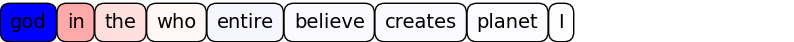

In [ ]:
plot_text_heatmap(
    words=lime_features,
    scores=lime_weights,
)

### SHAP

In [ ]:
import shap

# -------------------------------------------------------------- #
# Create SHAP text masker
# -------------------------------------------------------------- #
masker = shap.maskers.Text()

# -------------------------------------------------------------- #
# Create SHAP explainer
# -------------------------------------------------------------- #
explainer = shap.Explainer(
    pipeline_model.predict_proba,
    masker=masker,
)

# -------------------------------------------------------------- #
# Explain instance
# -------------------------------------------------------------- #
shap_exp = explainer([text])

# -------------------------------------------------------------- #
# Prediction details
# -------------------------------------------------------------- #
prediction_probs = pipeline_model.predict_proba([text])[0]

predicted_class_index = prediction_probs.argmax()

print("Input text:")
print(text)

print("\nPrediction probabilities:")
print(prediction_probs)

print(
    "\nPredicted class:",
    class_names[predicted_class_index],
)

# -------------------------------------------------------------- #
# Extract SHAP features + weights
# -------------------------------------------------------------- #
shap_features, shap_weights = extract_shap_explanation_details(
    shap_exp,
    class_index=1,
    top_k=num_features,
)

print("\nWeights:")
print(shap_weights)

print("\nFeatures:")
print(shap_features)

Input text:
I believe in god who creates the entire planet

Prediction probabilities:
[0.124 0.876]

Predicted class: christian

Weights:
[-0.05300000000000005, 0.016000000000000014, 0.008875000000000008, -0.002375000000000002, 0.0010000000000000009, -0.0010000000000000009, -0.0010000000000000009, -0.0005000000000000004, 0.0]

Features:
['god', 'in', 'the', 'entire', 'who', 'believe', 'creates', 'planet', 'I']


In [ ]:
plot_explainer_comparison(
    explanations={
        "SHAP": (shap_weights, shap_features)
    },
    title="SHAP",
)

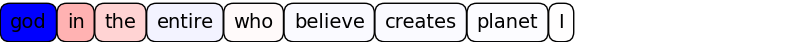

In [ ]:
plot_text_heatmap(
    words=shap_features,
    scores=shap_weights,
)

### Comparision together

In [ ]:
plot_explainer_comparison(
    explanations={
        "SMILE": (smile_weights, smile_features),
        "LIME": (lime_weights, lime_features),
        "SHAP": (shap_weights, shap_features),
    },
    title="Comparing SMILE, LIME, and SHAP",
)

## Case 3

In [ ]:

# -------------------------------------------------------------- #
# Input text
# -------------------------------------------------------------- #
text = "For those who believe in God most of the big questions are answered But for those of us who can't readily accept the God formula the big answers don't remain stone-written. We adjust to new conditions and discoveries. We are pliable. Love need not be a command nor faith a dictum. I am my own god. We are here to unlearn the teachings of the church state, and our educational system. We are here to drink beer. We are here to kill war. We are here to laugh at the odds and live our lives so well that Death will tremble to take us -- Charles Bukowski"
num_features = 6

### SMILE

In [ ]:
# -------------------------------------------------------------- #
# Create explainer
# -------------------------------------------------------------- #
explainer = SmileTextExplainer(
    embedding_name="word2vec-google-news-300",
    cache_dir="~/.cache/google_news_vectors",
    class_names=class_names,
)

# -------------------------------------------------------------- #
# Generate explanation
# -------------------------------------------------------------- #
exp = explainer.explain_instance(
    text,
    pipeline_model.predict_proba,
    num_features=num_features,
)


# -------------------------------------------------------------- #
# Prediction details
# -------------------------------------------------------------- #
prediction_probs = pipeline_model.predict_proba([text])[0]

predicted_class_index = prediction_probs.argmax()

print("Input text:")
print(text)

print("\nPrediction probabilities:")
print(prediction_probs)

print(
    "\nPredicted class:",
    class_names[predicted_class_index],
)


# -------------------------------------------------------------- #
# Extract features + weights
# -------------------------------------------------------------- #
smile_features, smile_weights = extract_explanation_details(exp)

print("\nWeights:")
print(smile_weights)

print("\nFeatures:")
print(smile_features)

Loading from cache: /root/.cache/google_news_vectors/GoogleNews-vectors-negative300.bin


Input text:
For those who believe in God most of the big questions are answered But for those of us who can't readily accept the God formula the big answers don't remain stone-written. We adjust to new conditions and discoveries. We are pliable. Love need not be a command nor faith a dictum. I am my own god. We are here to unlearn the teachings of the church state, and our educational system. We are here to drink beer. We are here to kill war. We are here to laugh at the odds and live our lives so well that Death will tremble to take us -- Charles Bukowski

Prediction probabilities:
[0.172 0.828]

Predicted class: christian

Weights:
[-0.04836119 -0.02482889 -0.01953172 -0.01924096  0.01580947  0.01547459]

Features:
[np.str_('god'), np.str_('system'), np.str_('don'), np.str_('kill'), np.str_('God'), np.str_('and')]


In [ ]:
plot_explainer_comparison(
    explanations={
        "SMILE": (smile_weights, smile_features)
    },
    title="SMILE",
)

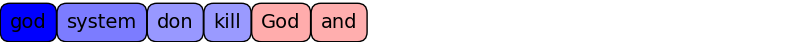

In [ ]:
plot_text_heatmap(
    words=smile_features,
    scores=smile_weights,
)

### LIME

In [ ]:
from lime.lime_text import LimeTextExplainer

# -------------------------------------------------------------- #
# Create explainer
# -------------------------------------------------------------- #
explainer = LimeTextExplainer(
    class_names=class_names
)

# -------------------------------------------------------------- #
# Generate explanation
# -------------------------------------------------------------- #
exp = explainer.explain_instance(
    text,
    pipeline_model.predict_proba,
    num_features=num_features,
)

# -------------------------------------------------------------- #
# Prediction details
# -------------------------------------------------------------- #
prediction_probs = pipeline_model.predict_proba([text])[0]

predicted_class_index = prediction_probs.argmax()

print("Input text:")
print(text)

print("\nPrediction probabilities:")
print(prediction_probs)

print(
    "\nPredicted class:",
    class_names[predicted_class_index],
)

# -------------------------------------------------------------- #
# Extract features + weights
# -------------------------------------------------------------- #
lime_features, lime_weights = extract_explanation_details(exp)

print("\nWeights:")
print(lime_weights)

print("\nFeatures:")
print(lime_features)

Input text:
For those who believe in God most of the big questions are answered But for those of us who can't readily accept the God formula the big answers don't remain stone-written. We adjust to new conditions and discoveries. We are pliable. Love need not be a command nor faith a dictum. I am my own god. We are here to unlearn the teachings of the church state, and our educational system. We are here to drink beer. We are here to kill war. We are here to laugh at the odds and live our lives so well that Death will tremble to take us -- Charles Bukowski

Prediction probabilities:
[0.172 0.828]

Predicted class: christian

Weights:
[-0.04599949 -0.02293877 -0.01814283  0.01656036 -0.01423032  0.0138147 ]

Features:
[np.str_('god'), np.str_('system'), np.str_('kill'), np.str_('God'), np.str_('don'), np.str_('and')]


In [ ]:
plot_explainer_comparison(
    explanations={
        "LIME": (lime_weights, lime_features)
    },
    title="LIME",
)

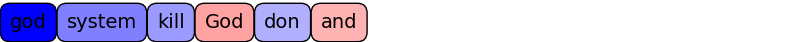

In [ ]:
plot_text_heatmap(
    words=lime_features,
    scores=lime_weights,
)

### SHAP

In [ ]:
import shap

# -------------------------------------------------------------- #
# Create SHAP text masker
# -------------------------------------------------------------- #
masker = shap.maskers.Text()

# -------------------------------------------------------------- #
# Create SHAP explainer
# -------------------------------------------------------------- #
explainer = shap.Explainer(
    pipeline_model.predict_proba,
    masker=masker,
)

# -------------------------------------------------------------- #
# Explain instance
# -------------------------------------------------------------- #
shap_exp = explainer([text])

# -------------------------------------------------------------- #
# Prediction details
# -------------------------------------------------------------- #
prediction_probs = pipeline_model.predict_proba([text])[0]

predicted_class_index = prediction_probs.argmax()

print("Input text:")
print(text)

print("\nPrediction probabilities:")
print(prediction_probs)

print(
    "\nPredicted class:",
    class_names[predicted_class_index],
)

# -------------------------------------------------------------- #
# Extract SHAP features + weights
# -------------------------------------------------------------- #
shap_features, shap_weights = extract_shap_explanation_details(
    shap_exp,
    class_index=1,
    top_k=num_features,
)

print("\nWeights:")
print(shap_weights)

print("\nFeatures:")
print(shap_features)

Input text:
For those who believe in God most of the big questions are answered But for those of us who can't readily accept the God formula the big answers don't remain stone-written. We adjust to new conditions and discoveries. We are pliable. Love need not be a command nor faith a dictum. I am my own god. We are here to unlearn the teachings of the church state, and our educational system. We are here to drink beer. We are here to kill war. We are here to laugh at the odds and live our lives so well that Death will tremble to take us -- Charles Bukowski

Prediction probabilities:
[0.172 0.828]

Predicted class: christian

Weights:
[-0.038109375, -0.013921874999999997, 0.006874999999999999, 0.006499999999999999, -0.004593750000000002, -0.004593750000000002]

Features:
['god.', 'We', 'God', 'in', 'our', 'system.']


In [ ]:
plot_explainer_comparison(
    explanations={
        "SHAP": (shap_weights, shap_features)
    },
    title="SHAP",
)

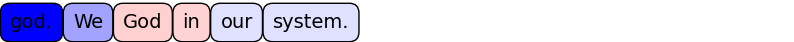

In [ ]:
plot_text_heatmap(
    words=shap_features,
    scores=shap_weights,
)

### Comparision together

In [ ]:
plot_explainer_comparison(
    explanations={
        "SMILE": (smile_weights, smile_features),
        "LIME": (lime_weights, lime_features),
        "SHAP": (shap_weights, shap_features),
    },
    title="Comparing SMILE, LIME, and SHAP",
)

## Case 4

In [ ]:
# -------------------------------------------------------------- #
# Input text
# -------------------------------------------------------------- #
text = "Is it just me or have you ever been in this phase wherein you became ignorant to the people you once loved completely disregarding their feelings/lives so you get to have something go your way and feel temporarily at ease. How did things change?"
num_features = 6

### SMILE

In [ ]:
# -------------------------------------------------------------- #
# Create explainer
# -------------------------------------------------------------- #
explainer = SmileTextExplainer(
    embedding_name="word2vec-google-news-300",
    cache_dir="~/.cache/google_news_vectors",
    class_names=class_names,
)

# -------------------------------------------------------------- #
# Generate explanation
# -------------------------------------------------------------- #
exp = explainer.explain_instance(
    text,
    pipeline_model.predict_proba,
    num_features=num_features,
)


# -------------------------------------------------------------- #
# Prediction details
# -------------------------------------------------------------- #
prediction_probs = pipeline_model.predict_proba([text])[0]

predicted_class_index = prediction_probs.argmax()

print("Input text:")
print(text)

print("\nPrediction probabilities:")
print(prediction_probs)

print(
    "\nPredicted class:",
    class_names[predicted_class_index],
)


# -------------------------------------------------------------- #
# Extract features + weights
# -------------------------------------------------------------- #
smile_features, smile_weights = extract_explanation_details(exp)

print("\nWeights:")
print(smile_weights)

print("\nFeatures:")
print(smile_features)

Loading from cache: /root/.cache/google_news_vectors/GoogleNews-vectors-negative300.bin


Input text:
Is it just me or have you ever been in this phase wherein you became ignorant to the people you once loved completely disregarding their feelings/lives so you get to have something go your way and feel temporarily at ease. How did things change?

Prediction probabilities:
[0.182 0.818]

Predicted class: christian

Weights:
[-0.01839467 -0.01756669 -0.01524161 -0.01233502 -0.01138026 -0.01040259]

Features:
[np.str_('you'), np.str_('people'), np.str_('it'), np.str_('just'), np.str_('so'), np.str_('something')]


In [ ]:
plot_explainer_comparison(
    explanations={
        "SMILE": (smile_weights, smile_features)
    },
    title="SMILE",
)

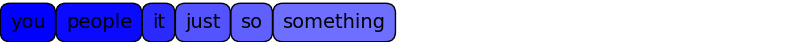

In [ ]:
plot_text_heatmap(
    words=smile_features,
    scores=smile_weights,
)

### LIME

In [ ]:
from lime.lime_text import LimeTextExplainer

# -------------------------------------------------------------- #
# Create explainer
# -------------------------------------------------------------- #
explainer = LimeTextExplainer(
    class_names=class_names
)

# -------------------------------------------------------------- #
# Generate explanation
# -------------------------------------------------------------- #
exp = explainer.explain_instance(
    text,
    pipeline_model.predict_proba,
    num_features=num_features,
)

# -------------------------------------------------------------- #
# Prediction details
# -------------------------------------------------------------- #
prediction_probs = pipeline_model.predict_proba([text])[0]

predicted_class_index = prediction_probs.argmax()

print("Input text:")
print(text)

print("\nPrediction probabilities:")
print(prediction_probs)

print(
    "\nPredicted class:",
    class_names[predicted_class_index],
)

# -------------------------------------------------------------- #
# Extract features + weights
# -------------------------------------------------------------- #
lime_features, lime_weights = extract_explanation_details(exp)

print("\nWeights:")
print(lime_weights)

print("\nFeatures:")
print(lime_features)

Input text:
Is it just me or have you ever been in this phase wherein you became ignorant to the people you once loved completely disregarding their feelings/lives so you get to have something go your way and feel temporarily at ease. How did things change?

Prediction probabilities:
[0.182 0.818]

Predicted class: christian

Weights:
[-0.01788121 -0.01750191 -0.01302675 -0.01210684 -0.01179819 -0.00945272]

Features:
[np.str_('you'), np.str_('people'), np.str_('it'), np.str_('just'), np.str_('so'), np.str_('something')]


In [ ]:
plot_explainer_comparison(
    explanations={
        "LIME": (lime_weights, lime_features)
    },
    title="LIME",
)

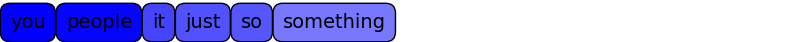

In [ ]:
plot_text_heatmap(
    words=lime_features,
    scores=lime_weights,
)

### SHAP

In [ ]:
import shap

# -------------------------------------------------------------- #
# Create SHAP text masker
# -------------------------------------------------------------- #
masker = shap.maskers.Text()

# -------------------------------------------------------------- #
# Create SHAP explainer
# -------------------------------------------------------------- #
explainer = shap.Explainer(
    pipeline_model.predict_proba,
    masker=masker,
)

# -------------------------------------------------------------- #
# Explain instance
# -------------------------------------------------------------- #
shap_exp = explainer([text])

# -------------------------------------------------------------- #
# Prediction details
# -------------------------------------------------------------- #
prediction_probs = pipeline_model.predict_proba([text])[0]

predicted_class_index = prediction_probs.argmax()

print("Input text:")
print(text)

print("\nPrediction probabilities:")
print(prediction_probs)

print(
    "\nPredicted class:",
    class_names[predicted_class_index],
)

# -------------------------------------------------------------- #
# Extract SHAP features + weights
# -------------------------------------------------------------- #
shap_features, shap_weights = extract_shap_explanation_details(
    shap_exp,
    class_index=1,
    top_k=num_features,
)

print("\nWeights:")
print(shap_weights)

print("\nFeatures:")
print(shap_features)

Input text:
Is it just me or have you ever been in this phase wherein you became ignorant to the people you once loved completely disregarding their feelings/lives so you get to have something go your way and feel temporarily at ease. How did things change?

Prediction probabilities:
[0.182 0.818]

Predicted class: christian

Weights:
[-0.014125000000000009, -0.011156250000000008, 0.008562499999999997, -0.006875000000000006, -0.006749999999999999, -0.006125000000000004]

Features:
['people', 'it', 'in', 'you', 'or', 'you']


In [ ]:
plot_explainer_comparison(
    explanations={
        "SHAP": (shap_weights, shap_features)
    },
    title="SHAP",
)

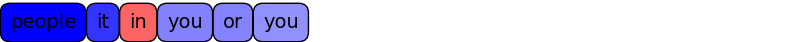

In [ ]:
plot_text_heatmap(
    words=shap_features,
    scores=shap_weights,
)

### Comparision together

In [ ]:
plot_explainer_comparison(
    explanations={
        "SMILE": (smile_weights, smile_features),
        "LIME": (lime_weights, lime_features),
        "SHAP": (shap_weights, shap_features),
    },
    title="Comparing SMILE, LIME, and SHAP",
)

## Case 5

In [ ]:
# -------------------------------------------------------------- #
# Input text
# -------------------------------------------------------------- #
text = "When will Americans recognize that southern conservatives (those who whine about Obama, Jim Crow appreciators) are the biggest problem with America and that nothing will get solved until they are put in their place?"
num_features = 6

### SMILE

In [ ]:
# -------------------------------------------------------------- #
# Create explainer
# -------------------------------------------------------------- #
explainer = SmileTextExplainer(
    embedding_name="word2vec-google-news-300",
    cache_dir="~/.cache/google_news_vectors",
    class_names=class_names,
)

# -------------------------------------------------------------- #
# Generate explanation
# -------------------------------------------------------------- #
exp = explainer.explain_instance(
    text,
    pipeline_model.predict_proba,
    num_features=num_features,
)


# -------------------------------------------------------------- #
# Prediction details
# -------------------------------------------------------------- #
prediction_probs = pipeline_model.predict_proba([text])[0]

predicted_class_index = prediction_probs.argmax()

print("Input text:")
print(text)

print("\nPrediction probabilities:")
print(prediction_probs)

print(
    "\nPredicted class:",
    class_names[predicted_class_index],
)


# -------------------------------------------------------------- #
# Extract features + weights
# -------------------------------------------------------------- #
smile_features, smile_weights = extract_explanation_details(exp)

print("\nWeights:")
print(smile_weights)

print("\nFeatures:")
print(smile_features)

Loading from cache: /root/.cache/google_news_vectors/GoogleNews-vectors-negative300.bin


Input text:
When will Americans recognize that southern conservatives (those who whine about Obama, Jim Crow appreciators) are the biggest problem with America and that nothing will get solved until they are put in their place?

Prediction probabilities:
[0.162 0.838]

Predicted class: christian

Weights:
[-0.05363614 -0.01685009  0.01051229 -0.00852224 -0.00788304  0.00687007]

Features:
[np.str_('Jim'), np.str_('Americans'), np.str_('in'), np.str_('place'), np.str_('until'), np.str_('and')]


In [ ]:
plot_explainer_comparison(
    explanations={
        "SMILE": (smile_weights, smile_features)
    },
    title="SMILE",
)

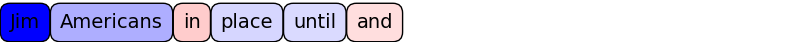

In [ ]:
plot_text_heatmap(
    words=smile_features,
    scores=smile_weights,
)

### LIME

In [ ]:
from lime.lime_text import LimeTextExplainer

# -------------------------------------------------------------- #
# Create explainer
# -------------------------------------------------------------- #
explainer = LimeTextExplainer(
    class_names=class_names
)

# -------------------------------------------------------------- #
# Generate explanation
# -------------------------------------------------------------- #
exp = explainer.explain_instance(
    text,
    pipeline_model.predict_proba,
    num_features=num_features,
)

# -------------------------------------------------------------- #
# Prediction details
# -------------------------------------------------------------- #
prediction_probs = pipeline_model.predict_proba([text])[0]

predicted_class_index = prediction_probs.argmax()

print("Input text:")
print(text)

print("\nPrediction probabilities:")
print(prediction_probs)

print(
    "\nPredicted class:",
    class_names[predicted_class_index],
)

# -------------------------------------------------------------- #
# Extract features + weights
# -------------------------------------------------------------- #
lime_features, lime_weights = extract_explanation_details(exp)

print("\nWeights:")
print(lime_weights)

print("\nFeatures:")
print(lime_features)

Input text:
When will Americans recognize that southern conservatives (those who whine about Obama, Jim Crow appreciators) are the biggest problem with America and that nothing will get solved until they are put in their place?

Prediction probabilities:
[0.162 0.838]

Predicted class: christian

Weights:
[-0.05175235 -0.01668596  0.01114849 -0.00773472 -0.00744458  0.00536944]

Features:
[np.str_('Jim'), np.str_('Americans'), np.str_('in'), np.str_('place'), np.str_('that'), np.str_('and')]


In [ ]:
plot_explainer_comparison(
    explanations={
        "LIME": (lime_weights, lime_features)
    },
    title="LIME",
)

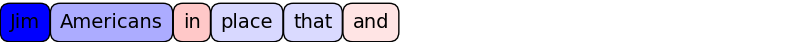

In [ ]:
plot_text_heatmap(
    words=lime_features,
    scores=lime_weights,
)

### SHAP

In [ ]:
import shap

# -------------------------------------------------------------- #
# Create SHAP text masker
# -------------------------------------------------------------- #
masker = shap.maskers.Text()

# -------------------------------------------------------------- #
# Create SHAP explainer
# -------------------------------------------------------------- #
explainer = shap.Explainer(
    pipeline_model.predict_proba,
    masker=masker,
)

# -------------------------------------------------------------- #
# Explain instance
# -------------------------------------------------------------- #
shap_exp = explainer([text])

# -------------------------------------------------------------- #
# Prediction details
# -------------------------------------------------------------- #
prediction_probs = pipeline_model.predict_proba([text])[0]

predicted_class_index = prediction_probs.argmax()

print("Input text:")
print(text)

print("\nPrediction probabilities:")
print(prediction_probs)

print(
    "\nPredicted class:",
    class_names[predicted_class_index],
)

# -------------------------------------------------------------- #
# Extract SHAP features + weights
# -------------------------------------------------------------- #
shap_features, shap_weights = extract_shap_explanation_details(
    shap_exp,
    class_index=1,
    top_k=num_features,
)

print("\nWeights:")
print(shap_weights)

print("\nFeatures:")
print(shap_features)

Input text:
When will Americans recognize that southern conservatives (those who whine about Obama, Jim Crow appreciators) are the biggest problem with America and that nothing will get solved until they are put in their place?

Prediction probabilities:
[0.162 0.838]

Predicted class: christian

Weights:
[-0.052375000000000047, -0.014750000000000013, 0.005750000000000005, 0.004562500000000004, 0.004500000000000004, 0.004125000000000004]

Features:
['Jim', 'Americans', 'and', 'the', 'in', 'are']


In [ ]:
plot_explainer_comparison(
    explanations={
        "SHAP": (shap_weights, shap_features)
    },
    title="SHAP",
)

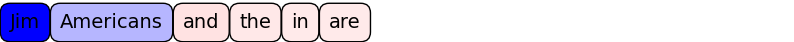

In [ ]:
plot_text_heatmap(
    words=shap_features,
    scores=shap_weights,
)

### Comparision together

In [ ]:
plot_explainer_comparison(
    explanations={
        "SMILE": (smile_weights, smile_features),
        "LIME": (lime_weights, lime_features),
        "SHAP": (shap_weights, shap_features),
    },
    title="Comparing SMILE, LIME, and SHAP",
)